In [1]:
import pandas as pd

# ParlaMint-SI analysis dataset preparation
## Merging the initial ParlaSent-SI dataset with aggregated scores

In [ ]:
def process_chunk(df_chunk):
    print(df_chunk.head())
def process_jsonl(file_path, chunksize=1000):
    df_list=[]
    for df_chunk in pd.read_json(file_path, lines=True, chunksize=chunksize):
        df_list.append(df_chunk)
    
    full_df = pd.concat(df_list, ignore_index=True)
    return full_df

file_path = '../../../ParlaSent-SI/ParlaMint-SI.meta.jsonl'
df_sent = process_jsonl(file_path, chunksize=1000)
df_sent.head()

In [ ]:
order = ['ID', 'sent_id', 'text', 'text_en', 'metadata', 'sent_annotations']
df_sent = df_sent.rename(columns={'logit':'sent_annotations', 'newdoc id':'ID'})
df_sent = df_sent[order]
df_sent.head()

In [ ]:
df_utt = pd.read_csv('../../Datasets/ParlaMint-SI/utt_labels_RF.tsv', delimiter='\t', encoding='utf-8')
df_utt.head()

In [5]:
df_utt = df_utt.rename(columns={'annotations':'utt_annotations'})

### Check for no. of utterances

In [ ]:
df1 = set(df_sent['ID'])
df2 = set(df_utt['ID'])

count_df1 = len(df1)
count_df2 = len(df2)

print(f"Number of unique utt_id in df1: {count_df1}")
print(f"Number of unique ID in df2: {count_df2}")

# Identify missing or extra IDs
missing_in_df2 = count_df1 - count_df2
extra_in_df2 = count_df2 - count_df1

print(f"IDs in df1 not in df2: {missing_in_df2}")
print(f"IDs in df2 not in df1: {extra_in_df2}")

### Merging the datasets

In [ ]:
dataset = pd.merge(df_sent, df_utt, on='ID')
dataset

## Adding metadata as columns

In [ ]:
import ast

metadata_df = pd.json_normalize(dataset['metadata'])
dataset = pd.concat([dataset, metadata_df], axis=1).drop(columns=['metadata'])
dataset.head()


In [ ]:
#dataset.to_csv('../../Datasets/Sentiment_Analysis/ParlaMint-SI.tsv', sep='\t', encoding='utf-8', index=False)

# Sentiment analysis of the ParlaMint-SI dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../../Datasets/Sentiment_Analysis/ParlaMint-SI.tsv', delimiter='\t', encoding='utf-8')
df.head()

,ID,sent_id,text,text_en,sent_annotations,utt_annotations,labels,sentiment,Text_ID,ID.1,...,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,"Dear fellow Members and fellow Members, ladies...",4.052144,2.42,Neutral Negative,Neutral,ParlaMint-SI-en_2022-04-06-SDZ8-Izredna-99,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Začenjam z nadaljevanjem 99. izredne seje Drža...,I'm starting with the 99th Extraordinary Meeti...,3.223034,2.42,Neutral Negative,Neutral,ParlaMint-SI-en_2022-04-06-SDZ8-Izredna-99,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Obveščen sem, da se današnje seje ne morejo ud...",I am informed that today's meeting cannot be a...,1.778516,2.42,Neutral Negative,Neutral,ParlaMint-SI-en_2022-04-06-SDZ8-Izredna-99,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Vse prisotne lepo pozdravljam!,I say hello to everyone who's here!,4.814360,2.42,Neutral Negative,Neutral,ParlaMint-SI-en_2022-04-06-SDZ8-Izredna-99,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Prehajamo na 10.,We're moving on to 10.,3.219104,2.42,Neutral Negative,Neutral,ParlaMint-SI-en_2022-04-06-SDZ8-Izredna-99,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953


In [2]:
df = df.drop(columns={'Text_ID', 'ID.1'})
df.head()

,ID,sent_id,text,text_en,sent_annotations,utt_annotations,labels,sentiment,Title,Date,...,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,"Dear fellow Members and fellow Members, ladies...",4.052144,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Začenjam z nadaljevanjem 99. izredne seje Drža...,I'm starting with the 99th Extraordinary Meeti...,3.223034,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Obveščen sem, da se današnje seje ne morejo ud...",I am informed that today's meeting cannot be a...,1.778516,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Vse prisotne lepo pozdravljam!,I say hello to everyone who's here!,4.814360,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Prehajamo na 10.,We're moving on to 10.,3.219104,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953


In [3]:
df.to_csv('../../Datasets/Sentiment_Analysis/ParlaMint-SI.tsv', sep='\t', encoding='utf-8', index=False)

In [4]:
utt = df.drop_duplicates(subset=['ID']).reset_index(drop=True)
utt.head()

,ID,sent_id,text,text_en,sent_annotations,utt_annotations,labels,sentiment,Title,Date,...,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,"Dear fellow Members and fellow Members, ladies...",4.052144,2.42,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Spoštovane kolegice in kolegi, gospe in gospodje!","Dear colleagues, ladies and gentlemen!",3.846659,3.88,Mixed Positive,Positive,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,NP,Poslanska skupina nepovezanih poslancev,-,-,ZorčičIgor,"Zorčič, Igor",M,1978
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Hvala tudi vam.,"Thank you, too.",4.758979,3.00,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Hvala lepa, predsedujoči.","Thank you very much, Chairman.",4.019485,3.19,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMP,notMinister,-,-,-,-,SlavinecMitja,"Slavinec, Mitja",M,1964
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Hvala tudi vam.,"Thank you, too.",4.758979,3.00,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953


### Removing procedural speeches for analysis

In [41]:
utt_filter = utt[utt['Speaker_role'] == 'Regular']
utt_filter

,ID,sent_id,text,text_en,sent_annotations,utt_annotations,labels,sentiment,Title,Date,...,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Spoštovane kolegice in kolegi, gospe in gospodje!","Dear colleagues, ladies and gentlemen!",3.846659,3.88,Mixed Positive,Positive,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,NP,Poslanska skupina nepovezanih poslancev,-,-,ZorčičIgor,"Zorčič, Igor",M,1978
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Hvala lepa, predsedujoči.","Thank you very much, Chairman.",4.019485,3.19,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2022-04-06,...,notMP,notMinister,-,-,-,-,SlavinecMitja,"Slavinec, Mitja",M,1964
5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u6,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Spoštovani, hvala za besedo.","Your Honor, thank you for your word.",3.833185,4.38,Mixed Positive,Positive,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,SAB,Stranka Alenke Bratušek,Opposition,Centre-left,BandelliMarko,"Bandelli, Marko",M,1967
7,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u8,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Hvala za besedo, podpredsednik.","Thank you for your word, Vice President.",3.653113,3.94,Mixed Positive,Positive,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,Konkretno,Konkretno,Coalition,Centre,ŽnidaričMojca,"Žnidarič, Mojca",F,1977
9,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u10,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Lep pozdrav!,Good-bye!,4.872236,4.92,Positive,Positive,Minutes of the National Assembly of the Republ...,2022-04-06,...,MP,notMinister,SNS,Slovenska nacionalna stranka,Opposition,Right to far-right,ŠiškoDušan,"Šiško, Dušan",M,1969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311337,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u237,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.seg5...,Hvala lepa.,Thank you very much.,4.084590,1.88,Neutral Negative,Neutral,Minutes of the National Assembly of the Republ...,2005-01-24,...,notMP,notMinister,NSi,Nova Slovenija – Krščanski demokrati,Coalition,Centre-right,BajukAndrej,"Bajuk, Andrej",M,1943
311339,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u239,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.seg5...,"Hvala, ker ste dovolili gospodu ministru dodat...",Thank you for allowing Mr Minister the extra t...,3.745592,2.52,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2005-01-24,...,MP,notMinister,LDS,Liberalna demokracija Slovenije,Opposition,Centre to centre-left,CviklMilanMartin,"Cvikl, Milan Martin",M,1959
311341,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u241,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.seg5...,"Na prvo vprašanje ni bilo odgovorjeno, sem sam...","The first question was not answered, I merely ...",1.818160,1.49,Mixed Negative,Negative,Minutes of the National Assembly of the Republ...,2005-01-24,...,MP,notMinister,LDS,Liberalna demokracija Slovenije,Opposition,Centre to centre-left,CviklMilanMartin,"Cvikl, Milan Martin",M,1959
311343,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u243,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.seg5...,"Dodatno vprašanje je pa seveda povezano s tem,...","However, the additional issue is, of course, l...",2.585003,2.75,Neutral Positive,Neutral,Minutes of the National Assembly of the Republ...,2005-01-24,...,MP,notMinister,LDS,Liberalna demokracija Slovenije,Opposition,Centre to centre-left,CviklMilanMartin,"Cvikl, Milan Martin",M,1959


In [42]:
utt_labels = utt_filter['labels'].value_counts()
utt_sentiment = utt_filter['sentiment'].value_counts()

## Checking label distribution (without procedural speech)

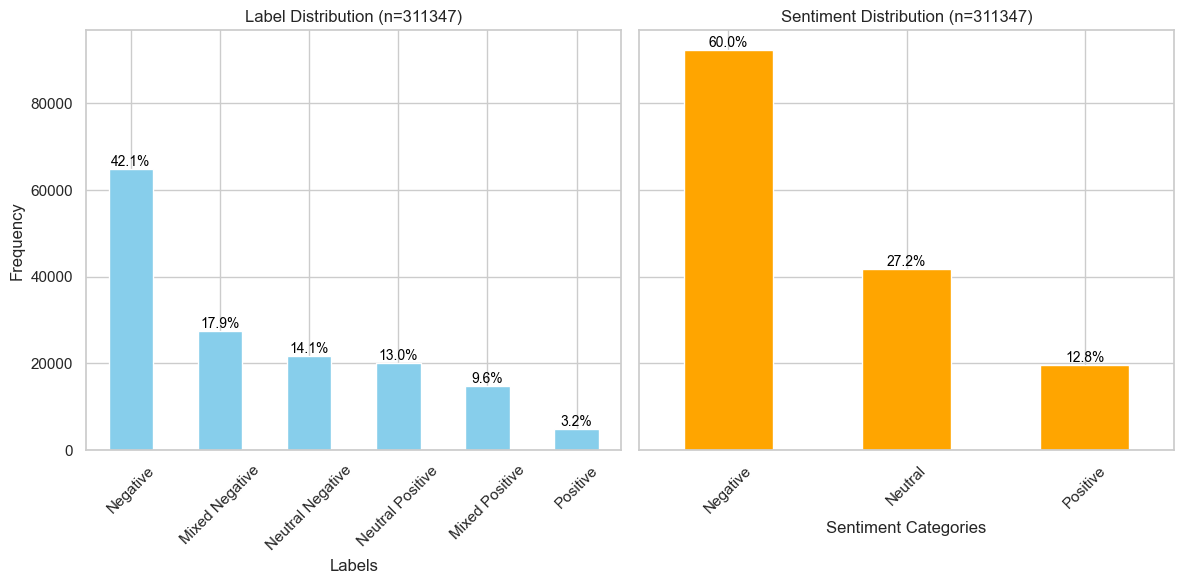

In [46]:
def add_percentage(ax, counts):
    total = counts.sum()
    for p in ax.patches:
        percentage = f"{(p.get_height() / total) * 100:.1f}%"
        ax.annotate(percentage,  (p.get_x() + p.get_width() / 2, p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='black')

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
utt_labels.plot(kind='bar', ax=axes[0], color = 'skyblue')
axes[0].set_title('Label Distribution (n=311347)')
axes[0].set_xlabel('Labels')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)
add_percentage(axes[0], utt_labels)

utt_sentiment.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Sentiment Distribution (n=311347)')
axes[1].set_xlabel('Sentiment Categories')
axes[1].tick_params(axis='x', rotation=45)
add_percentage(axes[1], utt_sentiment)

plt.tight_layout()
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_distribution.png', dpi=300)
plt.show()

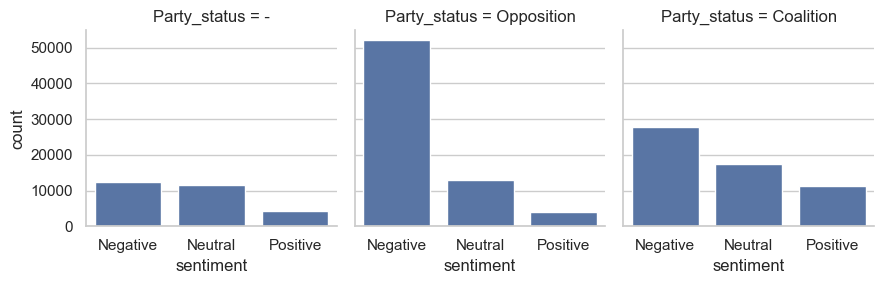

In [47]:
g = sns.FacetGrid(utt_filter, col="Party_status", margin_titles=True)
g.map(sns.countplot, "sentiment", order=["Negative", "Neutral", "Positive"])
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_per_Party_status.png', dpi=300)
plt.show()

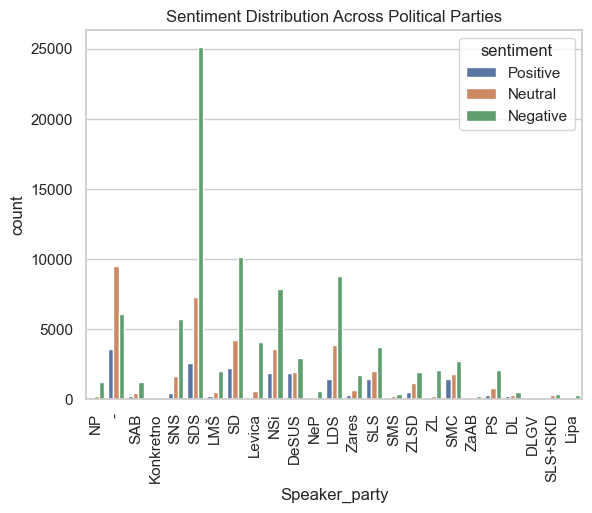

In [48]:
sns.countplot(data=utt_filter, x='Speaker_party', hue='sentiment', order=utt_filter['Speaker_party'].unique())
plt.xticks(rotation=90)
plt.title('Sentiment Distribution Across Political Parties')
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_per_Political_parties.png', dpi=300)

plt.show()

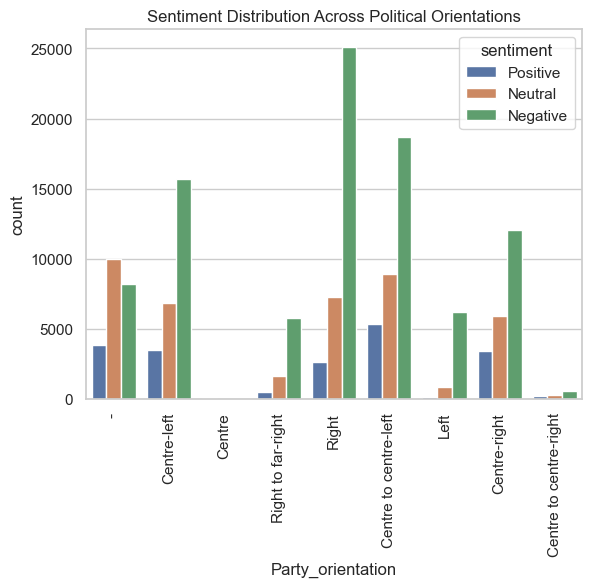

In [49]:
sns.countplot(data=utt_filter, x='Party_orientation', hue='sentiment', order=utt_filter['Party_orientation'].unique())
plt.xticks(rotation=90)
plt.title('Sentiment Distribution Across Political Orientations')
plt.savefig('../../Figures/Sentiment_Analysis/Sentiment_per_Orientation.png', dpi=300)
plt.show()